[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b — Bayesian Optimization with TuRBO

## 1. Overview

This notebook runs **TuRBO**, the proposed method for multi-band antenna tilt coordination, and reads it against the
baselines of notebook 03a.

**Question.** Does a model-guided search find a better tilt configuration than random search for the same number of
ray-traced evaluations, and than the rule-based sweep at any budget?

**Goals.**

- Run TuRBO on the same simulator, scenario, objective and evaluation budget as random search.
- Show how the trust region spends that budget.
- Measure what the best configuration changes on every KPI, and where on the map, beside both baselines.

The problem formulation is described in notebook 01, the setup tables and the objective $J$ in notebook 03a
(sections 3 and 7); they are not repeated here.

**Outputs.** One run directory per seed under `outputs/optim/turbo/`, tables under `reports/tables/03b_turbo/`,
figures under `reports/figures/03b_turbo/`. **Requirements.** A CUDA GPU, and notebook 03a run first. The shell
equivalent of the run is `task bo`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt"), ("botorch", "botorch")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.methods.turbo.search import TURBO, TrustRegion
from src.optim.objective import MAXIMISED, score_frame
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds, matched to 03a: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("turbo", "random", "rule")

## 2. Method

TuRBO (Eriksson et al., 2019, `optim/method=turbo`) keeps one trust region, a box around the best point found so far,
and searches only inside it:

1. Evaluate the current configuration, then an initial Sobol design of `n_init` points. It is the same design random
   search starts with, so the two differ only in where they look afterwards.
2. Fit a Gaussian process to the objective $J$ of every evaluation since the last restart, in the unit cube the tilt
   box is rescaled to.
3. Centre the trust region on the best point, with side lengths stretched along the dimensions the GP finds smooth.
4. Draw candidates inside the region, perturbing a random subset of dimensions, and pick a batch of `batch_size` by
   Thompson sampling from the GP posterior.
5. Ray-trace the batch. After `success_tolerance` improving rounds the region doubles; after the failure tolerance of
   non-improving rounds it halves.
6. When the region shrinks below `length_min`, restart: a fresh Sobol design and a GP that forgets the collapsed
   region. Restarts spend the same budget.

Every candidate is ray-traced and scored exactly as in 03a; the GP only chooses where to look, and no reported number
comes from it.

## 3. Configuration

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)

turbo_cfg = load_config(overrides=["optim/method=turbo", *CONFIG_OVERRIDES])
budget = turbo_cfg.optim.method.budget
region = TrustRegion.from_config(turbo_cfg, space.n_dim, int(budget.batch_size))
settings = pd.DataFrame(
    {
        "Parameter": [
            "Optimized variables",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Batch size",
            "Trust region length: initial, minimum, maximum",
            "Success tolerance (rounds)",
            "Failure tolerance (rounds)",
            "Search seeds",
            "Solutions published",
        ],
        "Value": [
            space.n_dim,
            int(budget.n_init) + int(budget.n_iter),
            f"n_init={budget.n_init}, n_iter={budget.n_iter}",
            region.batch_size,
            f"{region.length_init:g}, {region.length_min:g}, {region.length_max:g}",
            region.success_tolerance,
            region.failure_tolerance,
            ", ".join(map(str, SEEDS)),
            int(turbo_cfg.optim.n_solutions),
        ],
    }
)
save_table(settings, "turbo_configuration")
settings

,Parameter,Value
0,Optimized variables,36
1,Evaluations (excluding the incumbent),144
2,Budget split,"n_init=16, n_iter=128"
3,Batch size,3
4,"Trust region length: initial, minimum, maximum","0.8, 0.0078125, 1.6"
5,Success tolerance (rounds),3
6,Failure tolerance (rounds),12
7,Search seeds,42
8,Solutions published,4


## 4. Runs

A TuRBO run already on disk for the same seed and the current scenario is reused; delete its directory under
`outputs/optim/turbo/` to repeat it. Runs from an earlier scenario are ignored. The baseline runs are read from disk,
not repeated, and every run is checked comparable with the current radio map.

In [4]:
scenario = str(baseline["scenario_id"])


def on_disk():
    # The newest finished run of each method and seed on the current scenario.
    current = [r for r in run_store.discover(cfg.optim.output.dir) if r.scenario_id == scenario]
    return run_store.latest_per_method_and_seed(current)


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("turbo", seed) not in done:
        run(load_config(overrides=["optim/method=turbo", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

runs = [
    r
    for r in on_disk()
    if r.method == "rule" or (r.method in ("turbo", "random") and r.seed in SEEDS)
]
missing = [m for m in METHODS if not any(r.method == m for r in runs)]
if missing:
    raise run_store.RunError(
        f"No {', '.join(missing)} run on scenario {scenario}; run notebook 03a first."
    )
checks = run_store.verify(runs, baseline)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
best = compare.best_run_per_method(runs, cfg)
turbo = best["turbo"]

WARNING skipping outputs\optim\random\2026-09-16_08-25-34: No outputs\optim\random\2026-09-16_08-25-34\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\random\2026-09-16_14-49-31: No outputs\optim\random\2026-09-16_14-49-31\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\random\2026-09-17_03-21-43: No outputs\optim\random\2026-09-17_03-21-43\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\rule\2026-09-16_08-34-27: No outputs\optim\rule\2026-09-16_08-34-27\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\rule\2026-09-16_15-01-07: No outputs\optim\rule\2026-09-16_15-01-07\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_08-36-09: No outputs\optim\turbo\2026-09-16_08-36-09\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_14-32-24: No outputs\optim\turbo

WARNING skipping outputs\optim\rule\2026-09-16_08-34-27: No outputs\optim\rule\2026-09-16_08-34-27\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\rule\2026-09-16_15-01-07: No outputs\optim\rule\2026-09-16_15-01-07\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_08-36-09: No outputs\optim\turbo\2026-09-16_08-36-09\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_14-32-24: No outputs\optim\turbo\2026-09-16_14-32-24\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-17_03-02-08: No outputs\optim\turbo\2026-09-17_03-02-08\evaluation.parquet. The run did not finish writing.


3 runs; 21 of 21 comparability checks hold


## 5. Search Progress

Best objective found so far per evaluation, from the search history (UE-counted terms over the MDT), for TuRBO and
both baselines. With several seeds the line is the mean and the band spans the best and worst seed.

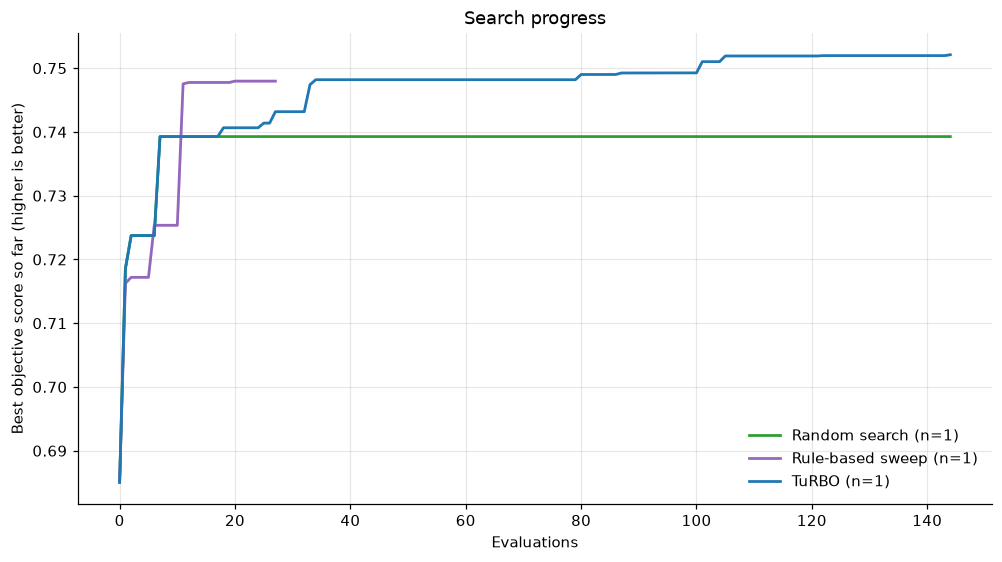

In [5]:
figure = plots.convergence_plot(compare.convergence(runs, cfg))
save_fig(figure, "search_progress")
plt.show()

### Where TuRBO spent its budget

Every evaluation of TuRBO's best run, marked by what proposed it. A Sobol block after the initial design is a restart.

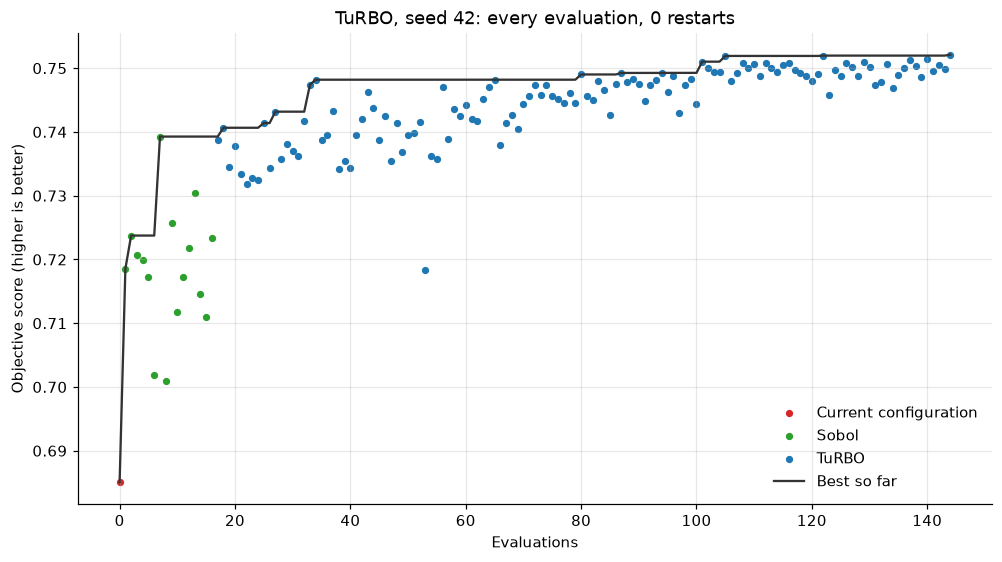

,Evaluations,Mean score,Best score
Proposed by,,,
Current configuration,1,0.6851,0.6851
Sobol,16,0.7186,0.7393
TuRBO,128,0.7447,0.7521


In [6]:
history = turbo.history.assign(score=lambda frame: score_frame(frame, cfg))
proposer = history["generation_node"].replace({"attached": "Current configuration"})
colours = {
    "Current configuration": plots.COLOURS["incumbent"],
    "Sobol": plots.COLOURS["random"],
    TURBO: plots.COLOURS["turbo"],
}
from_model = (history["generation_node"] == TURBO).to_numpy()
# A restart is a Sobol row directly after a trust-region proposal.
restarts = int((~from_model[1:] & from_model[:-1]).sum())

figure, axis = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
for name, group in history.groupby(proposer, sort=False):
    axis.scatter(group["iteration"], group["score"], s=14, color=colours[name], label=name)
axis.plot(history["iteration"], history["score"].cummax(), color="0.2", lw=1.5, label="Best so far")
axis.set_xlabel("Evaluations")
axis.set_ylabel("Objective score (higher is better)")
axis.set_title(f"TuRBO, seed {turbo.seed}: every evaluation, {restarts} restarts")
axis.legend()
save_fig(figure, "turbo_evaluations")
plt.show()

by_proposer = history.groupby(proposer, sort=False)["score"].agg(["size", "mean", "max"])
by_proposer = by_proposer.rename(
    columns={"size": "Evaluations", "mean": "Mean score", "max": "Best score"}
).rename_axis("Proposed by")
save_table(by_proposer.reset_index(), "turbo_evaluations_by_proposer")
by_proposer

**Observations.** Random search stops improving inside the shared Sobol design, and the rule-based sweep gets
nearly all of its gain from its first pass. TuRBO starts from the same design and keeps improving through the whole
budget in small steps; on the search score it passes random search soon after the design and the sweep within a few
dozen evaluations. The trust-region proposals score higher on average than the design points, so the model is steering towards
better configurations rather than scattering. The region never collapsed, so no restart was spent, and the best
configuration is the very last evaluation: the search was still improving when the budget ran out.

## 6. Best Tilt Configuration

The deliverable of TuRBO's best run: current and proposed tilt per cell-band. Negative change is uptilt.

TuRBO: run 2026-09-17_07-57-05, seed 42, best evaluation 144


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,7.7810,10.6262,-7.7810
1,2600 MHz,12,12,7.0297,10.6104,-7.0297
2,700 MHz,12,12,7.4800,11.9352,-7.4703


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,8.6506,-3.3494,0.0,15.0
1,n0c0,1800 MHz,12.0,1.3738,-10.6262,0.0,15.0
2,n0c0,700 MHz,12.0,2.6758,-9.3242,0.0,15.0
3,n0c1,2600 MHz,12.0,2.3407,-9.6593,0.0,15.0
4,n0c1,1800 MHz,12.0,4.7417,-7.2583,0.0,15.0
5,n0c1,700 MHz,12.0,3.6049,-8.3951,0.0,15.0
6,n0c2,2600 MHz,12.0,3.3161,-8.6839,0.0,15.0
7,n0c2,1800 MHz,12.0,2.1226,-9.8774,0.0,15.0
8,n0c2,700 MHz,12.0,5.1526,-6.8474,0.0,15.0
9,n1c0,2600 MHz,12.0,4.2175,-7.7825,0.0,15.0


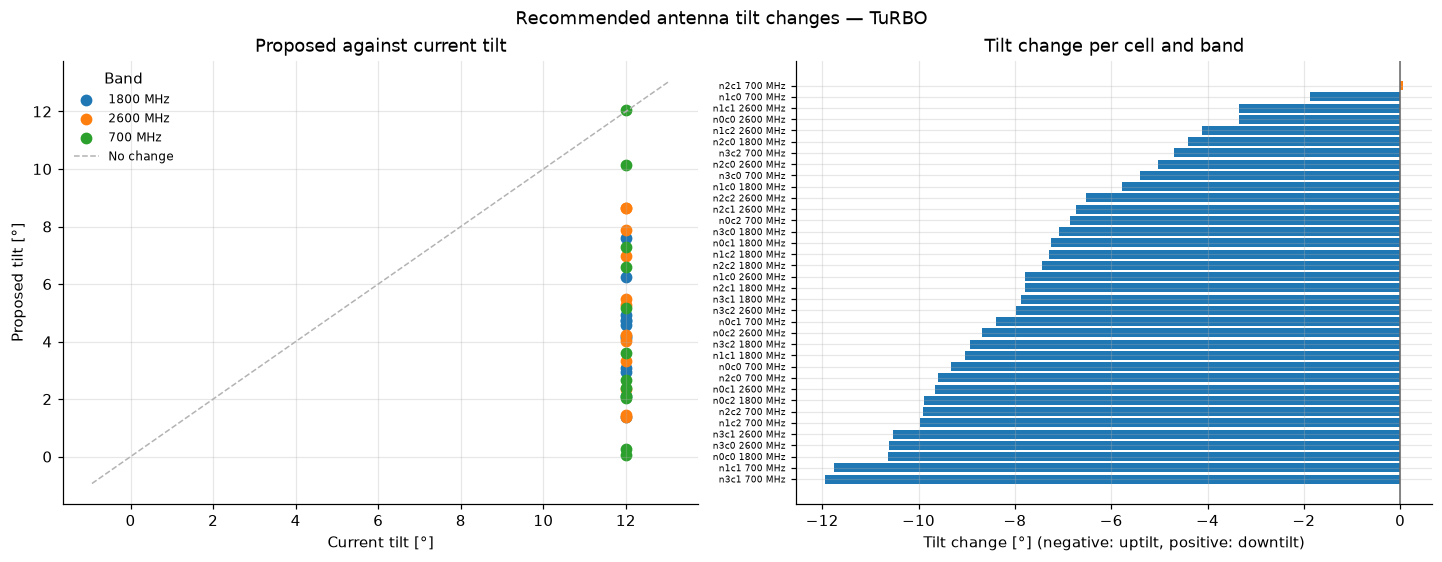

In [7]:
tilt = readable(turbo.best_tilt)
save_table(tilt, "best_tilt_turbo")
summary = readable(compare.tilt_movement(turbo))
save_table(summary, "tilt_movement_turbo")
print(
    f"{label('turbo')}: run {turbo.run_id}, seed {turbo.seed}, best evaluation {turbo.best_index}"
)
display(summary)
display(tilt)
figure = plots.tilt_movement_plot(turbo.best_tilt, "turbo")
save_fig(figure, "tilt_movement_turbo")
plt.show()

**Observations.** TuRBO uptilts almost every cell-band, like both baselines, and by a similar amount on
average per band. Unlike the sweep, the amount varies per cell-band: some are moved close to the lower tilt bound and
one is left practically unchanged. With a single seed it is not established which of these per-cell differences
matter and which are where the trust region happened to be when the budget ended.

## 7. Final Results

### KPI comparison

TuRBO's best configuration against the current one, on every UE. Relative improvement is signed so that positive is
better whichever direction the KPI runs, as in 03a:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

Then every method side by side: what its best run found on every UE, and what it cost.

In [8]:
table = compare.delta_table(turbo.incumbent_kpi, turbo.best_kpi)
sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
table = readable(table).rename(
    columns={
        "direction": "Direction",
        "before": "Initial",
        "after": label("turbo"),
        "delta": "Change",
        "verdict": "Verdict",
        "improvement_pct": "Improvement [%]",
    }
)
save_table(table, "kpi_comparison_turbo")
display(table)

results = readable(compare.method_table(runs, cfg).drop(columns=["run"]))
save_table(results, "method_results")
results

,KPI,Direction,Initial,TuRBO,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1840,0.1659,-0.0181,better,9.8344
1,Co-band overlap rate,minimise,0.2689,0.2730,0.0041,worse,-1.5420
2,Served UE ratio,maximise,0.4121,0.5133,0.1012,better,24.5661
3,Weak coverage rate,minimise,0.4063,0.2632,-0.1432,better,35.2329
4,Cell-edge RSRP,maximise,-112.2728,-109.3873,2.8855,better,2.5701
5,Radio utility J_radio,maximise,0.5568,0.5864,0.0296,better,5.3153
6,Load utility J_load,maximise,0.8349,0.8656,0.0307,better,3.6734


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Radio utility J_radio,Load utility J_load,Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,12.1439,15.3656,0.1680,0.2810,0.5069,0.2847,-109.9979,0.5777,0.8616,0.7055,6,1
1,Rule-based sweep,42,28,20,1.1977,2.2115,0.1639,0.2744,0.5163,0.2594,-109.3382,0.5843,0.8681,0.7122,6,1
2,TuRBO,42,145,144,9.8646,19.4349,0.1659,0.2730,0.5133,0.2632,-109.3873,0.5864,0.8656,0.7124,6,1


**Observations.** On all UEs TuRBO improves six of the seven measures and worsens only the co-band overlap
rate, the same pattern as both baselines. Its objective is level with the rule-based sweep's and above random search's:
it has the highest radio utility and the lowest overlap rate of the three, while the sweep stays slightly ahead on
holes, weak coverage, served ratio, cell-edge RSRP and load utility. TuRBO spent less ray-tracing time than random
search for the same number of evaluations, but the longest wall clock of all three, because each round also fits a
GP. As in 03a, the MDT and all-UE views rank the shortlist differently: a non-recommended solution scores higher on
all UEs than the recommended one.

## 8. Coverage Map Comparison

Best-server RSRP before and after TuRBO, and the tiles that crossed the coverage-hole threshold; then the RSRP change
of each method's best configuration on one scale. Crimson triangles are the masts.

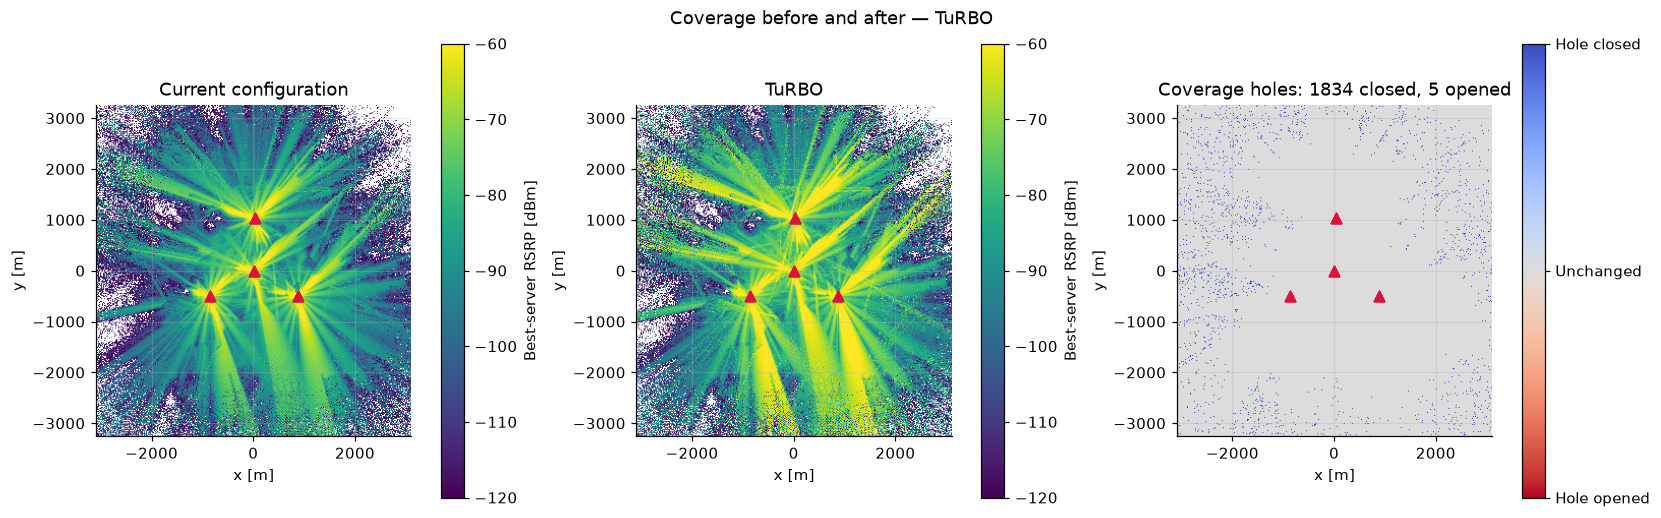

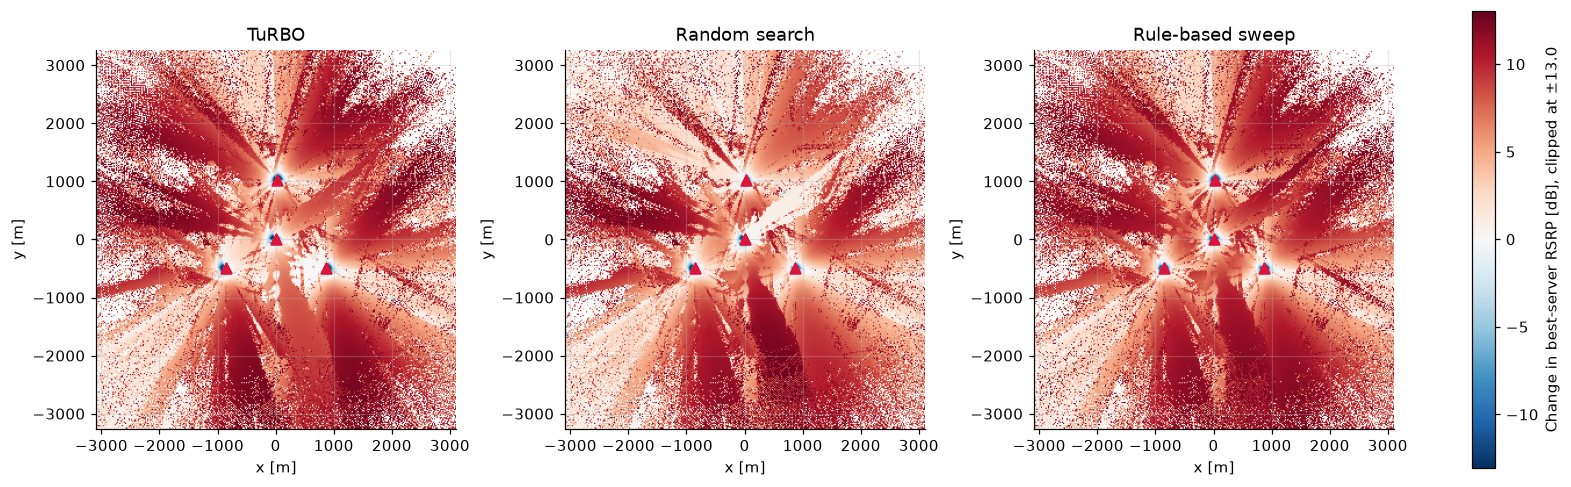

In [9]:
best_rsrp = {"incumbent": max_rsrp(baseline["rsrp_dbm"].astype(float))}
best_rsrp.update({m: max_rsrp(best[m].radio_map["rsrp_dbm"].astype(float)) for m in METHODS})

figure = plots.coverage_maps(
    best_rsrp["incumbent"], best_rsrp["turbo"], baseline, cfg, cells=cells, name="turbo"
)
save_fig(figure, "coverage_before_after_turbo")
plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

**Observations.** TuRBO's RSRP change map looks much like the sweep's: signal drops in a small area beside each
mast and rises by several dB across most of the scene, with the strongest gains along the beams towards the scene
edges. Random search's map is patchier, with weaker gains in several sectors. The holes that close lie in the outer
parts of the scene, away from the nodes.

## 9. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs, for the current configuration and
each method's best. Demand is the incumbent's for every configuration, so the weights do not move. Mean overlapping
neighbours is the diagnostic defined in 03a section 6; no score reads it.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,TuRBO: Share of area,TuRBO: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1840,0.0000,0.1659,0.0000,0.1680,0.0033,0.1639,0.0000
1,weak,0.4063,0.9208,0.2632,0.7781,0.2847,0.8065,0.2594,0.7731
2,good,0.4097,0.0792,0.5709,0.2219,0.5473,0.1901,0.5767,0.2269


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.2689,0.8818
1,TuRBO,0.2730,0.9371
2,Random search,0.2810,0.9013
3,Rule-based sweep,0.2744,1.0179


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10066.0,0.5879,-1.5773,4.0259,61.1037,0.2833,0.0533,0.0754
1,TuRBO,10066.0,0.4867,-0.6874,5.9724,48.1178,0.3780,0.0533,0.0820
2,Random search,10066.0,0.4931,-0.9727,6.0582,47.6475,0.3701,0.0566,0.0802
3,Rule-based sweep,10066.0,0.4837,-0.8595,6.2215,46.7724,0.3864,0.0499,0.0801


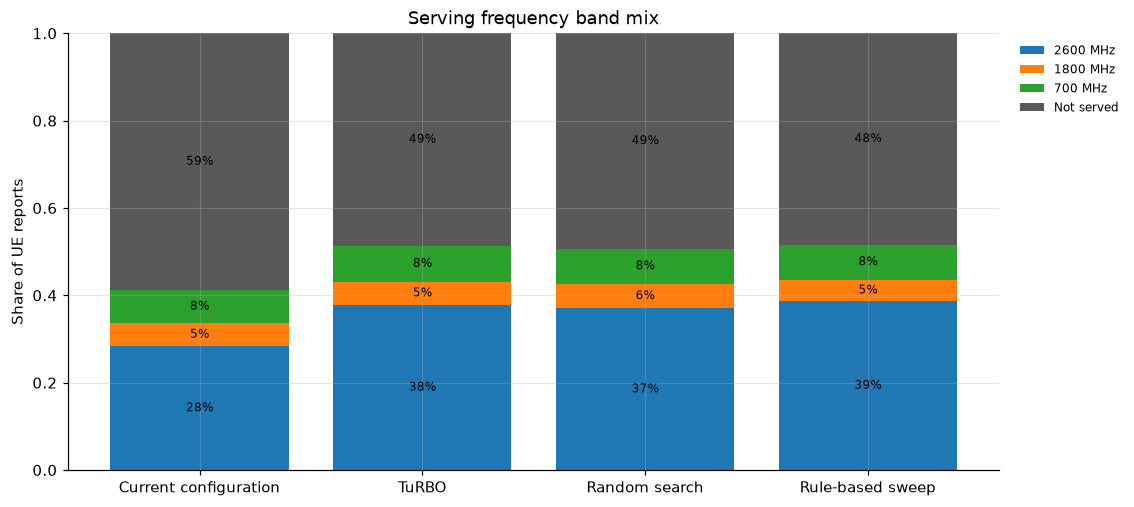

In [10]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [turbo.incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [
            mean_overlap_neighbors(c.rsrp) for c in configurations.values()
        ],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print(
    "Band preference, most preferred first:",
    ", ".join(label(b) for b in cfg.kpi.capacity.band_preference),
)
service = {
    name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()
}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

### Coverage holes

The current configuration has essentially no demand on hole tiles, and TuRBO keeps it that way, while random search
opens a small share on tiles with demand. The hole-rate gain is therefore by area, not by users.

### Coverage overlap

All three methods raise overlap slightly. TuRBO raises the overlap rate least and the mean number of overlapping
neighbours less than the sweep: letting cells on one band tilt differently limits how far every cell reaches into its
neighbours.

### Multi-band coordination

As with the baselines, the fewer unserved UEs are absorbed mostly by 2600 MHz, the preferred band, while the 1800 MHz
and 700 MHz shares barely move. TuRBO has the best 10th-percentile served SINR of the three configurations, and a
median close to the baselines.

### Weak coverage

Weak coverage falls sharply by area and the share of demand on weak tiles falls by about as much as with the sweep,
but most demand still sits on weak tiles. Per-cell tilt freedom did not remove that problem at this budget.

## 10. Key Observations

- TuRBO finds the same broad uptilt the baselines found, and like them its gain over the current configuration
  is mostly that uptilt.
- At the same budget and seed it beats random search on the objective and on every KPI, so the model-guided search
  does add value over sampling the box.
- It only draws level with the three-variable rule-based sweep on $J$, after many times the sweep's evaluations; the
  two trade small margins on individual KPIs.
- The search was still improving at its last evaluation, so the result is limited by the budget rather than by the
  trust region collapsing.
- These are one seed on one scenario; notebook 04 reports intervals over seeds.

## 11. Limitations

- **Budget.** The best point is the last evaluation and the region never collapsed, so a larger budget may
  still improve the result; this run does not show where TuRBO levels off.
- **Cost.** Every candidate is a full ray trace, and each round adds a GP fit, which grows with the evaluations since
  the last restart; wall clock exceeds random search at equal evaluations.
- **One trust region.** TuRBO searches around one incumbent; restarts are its only way to leave that basin, and none
  happened here.
- **Search on the MDT.** The GP models the MDT-scored objective, which does not rank solutions exactly as the all-UE
  re-score does.
- **Winner's curse.** The winner is the best of many evaluations under one solver seed, so its score is biased
  upward (notebook 04, threats to validity).
- **No movement constraint.** Tilt change is reported, not penalised, so the proposal moves nearly every antenna.

## 12. Conclusion

TuRBO is a working, reproducible model-guided search for multi-band tilt on this scenario. It:

- beats random search at the same budget and seed, starting from the same Sobol design;
- reaches the rule-based sweep's objective with per-cell-band tilts, and with the lowest co-band overlap of the three
  methods;
- follows the same trade-off as the baselines: uptilting reduces holes and weak coverage by area at the cost of
  slightly more overlap;
- was still improving when its budget ended.

Whether that margin over the sweep holds, and justifies TuRBO's cost, is decided over seeds in notebook 04.